# Attempt to forecast the price of MSFT by analyzing the prices of multiple stocks, including MSFT, over several consecutive days leading up to the target day.
#### N.B. Different setup from HW1

In [1]:
from torch.utils.data import DataLoader,Dataset

class StockDataset(Dataset):
    def __init__(self,X,Y,days):
        self.X = X
        self.Y = Y.reshape(-1)
        self.days = days # days ahead for prediction

    def __len__(self):
        return (len(self.Y)-self.days)

    def __getitem__(self,index):
        x=self.X[:,index:index+self.days]
        y=self.Y[index+self.days]
        # print(x.shape)
        return x,y



In [2]:
# !pip install pandas
# !pip install yfinance
import numpy as np
from numpy import exp, sum, log, log10
import yfinance as yf
import pandas as pd

def get_price(tick,start='2020-01-01',end=None):
    return yf.Ticker(tick).history(start=start,end=end)['Close']

def get_prices(tickers,start='2020-01-01',end=None):
    df=pd.DataFrame()
    for s in tickers:
        df[s]=get_price(s,start,end)
    return df

feature_stocks=['tsla','meta','nvda','amzn','nflx','gbtc','gdx','intc','dal','c','goog','aapl','msft','ibm','hp','orcl','sap','crm','hubs','twlo']
predict_stock='msft'

# getting data
start_date='2020-01-01'

allX=get_prices(feature_stocks,start=start_date)
ally=get_prices([predict_stock],start=start_date)

In [3]:
import torch.utils.data as data
import torch

stockData = StockDataset(allX.to_numpy().transpose().astype(np.float32),ally.to_numpy().astype(np.float32),days=5)
train_set_size = int(len(stockData)*0.7)
valid_set_size = int(len(stockData)*0.2)
test_set_size = len(stockData)-train_set_size-valid_set_size

train_set, valid_set, test_set = data.random_split(stockData,[train_set_size,valid_set_size,test_set_size],\
                                              generator=torch.Generator().manual_seed(42))

batch_size = train_set_size # use entire dataset as batch
train_dataloader = DataLoader(train_set,batch_size=batch_size,shuffle=True)  # input:(20,5), label:1
valid_dataloader = DataLoader(valid_set,batch_size=batch_size,shuffle=False)
test_dataloader = DataLoader(test_set,batch_size=batch_size,shuffle=False)

#### You have total freedom of your MLP. But your MLP should take the last five day ($5 \times 20=100$) prices as input and you have to add dropout into your network.

## 1a. Create a subclass of pytorch_lightning.LightningModule. It should include \_\_init\_\_, training_step, validation_step, configure_optimizers in the class. (6 points)

In [25]:
!pip install pytorch_lightning
import torch
import torch.nn as nn
import pytorch_lightning as pl


class MSFTPriceMLP(pl.LightningModule):
    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int] = [256, 128, 64, 32],
        dropout: float = 0.2,
        lr: float = 1e-4,
        weight_decay: float = 1e-5,
    ):
        super().__init__()
        self.save_hyperparameters()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))  # predict next MSFT price

        self.model = nn.Sequential(*layers)
        self.criterion = nn.MSELoss()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x).squeeze(-1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)

        self.log(
            "train_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=x.size(0),
        )
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)

        self.log(
            "val_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=x.size(0),
        )
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(),
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay
        )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=3
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "frequency": 1,
            },
        }

## 1b. Create a subclass of pytorch_lightning.LightningDataModule. It should include \_\_init\_\_, train_dataloader, and val_dataloader in the class. (4 points)

In [26]:
import pytorch_lightning as pl
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd



class MSFTDataModule(pl.LightningDataModule):
    def __init__(
        self,
        allX,
        allY,
        feature_cols=None,
        target_col: str = "Close",
        window_size: int = 20,
        batch_size: int = 4,
        num_workers: int = 0,
        train_ratio: float = 0.7,
        val_ratio: float = 0.15,
    ):
        super().__init__()
        self.allX = allX
        self.allY = allY
        self.feature_cols=['tsla','meta','nvda','amzn','nflx','gbtc','gdx','intc','dal','c','goog','aapl','msft','ibm','hp','orcl','sap','crm','hubs','twlo']
        self.target_col = "msft"
        self.window_size = window_size
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.train_ratio = train_ratio
        self.val_ratio = val_ratio

        self.train_dataset = None
        self.val_dataset = None
        self.test_dataset = None

        self.feature_mean = None
        self.feature_std = None

    def setup(self, day=5, stage=None):

        X = self.allX
        y = self.allY
        all_datas = StockDataset(X.to_numpy().transpose().astype(np.float32), y.to_numpy().astype(np.float32),days=day)
        total_size = len(all_datas)
        train_size = int(total_size * self.train_ratio)
        val_size = int(total_size * self.val_ratio)
        test_size = total_size - train_size - val_size
        print(total_size, train_size, val_size, test_size)
        train_set, valid_set, test_set = data.random_split(all_datas,[train_size, val_size, test_size])

        self.train_dataset = train_set
        self.val_dataset = valid_set
        self.test_dataset = test_set

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=True,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True,
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True,
        )

## 1c. Complete the rest of the code and train the model with 70% of the data. You should set aside 15% of the data each for validation and testing.  Show the training and validation MSE (5 points)

1562 1093 234 235


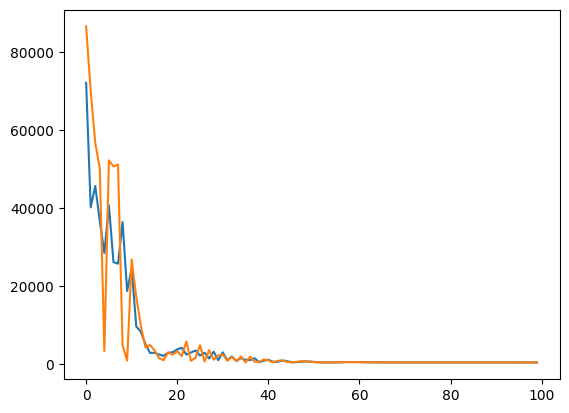

test_loss:  332.4715482097561


In [27]:
data_module = MSFTDataModule(allX, ally)
data_module.setup()
model = MSFTPriceMLP(input_dim=100)
train_dataloader = data_module.train_dataloader()
val_dataloader = data_module.val_dataloader()
test_dataloader = data_module.test_dataloader()

EPOCH = 100
training_losses, val_losses, test_losses = [], [], []
# training
model.train()
configs = model.configure_optimizers()
optimizer = configs["optimizer"]
scheduler = configs["lr_scheduler"]["scheduler"]
train_losses_by_epoch = []
val_losses_by_epoch = []
for epoch in range(EPOCH):
   training_losses = []
   for train_x, train_y in train_dataloader:
      #  print(train_x.shape, train_y.shape)
       train_x = train_x.reshape(-1, 100)
       loss = model.training_step((train_x, train_y), 0)
       loss.backward()
       optimizer.step()
       training_losses.append(loss.item())
   train_losses_by_epoch.append(np.mean(training_losses))
   scheduler.step(np.mean(training_losses))

   model.eval()
   with torch.no_grad():
      val_losses = []
      for val_x, val_y in val_dataloader:
        val_x = val_x.reshape(-1, 100)
        loss = model.validation_step((val_x, val_y), 0)
        val_losses.append(loss.item())
      val_losses_by_epoch.append(np.mean(val_losses))

from matplotlib import pyplot as plt
plt.plot(train_losses_by_epoch, label='train')
plt.plot(val_losses_by_epoch, label='val')
plt.show()

model.eval()
with torch.no_grad():
    losses = []
    for test_x, test_y in test_dataloader:
      test_x = test_x.reshape(-1, 100)
      loss = model.validation_step((test_x, test_y), 0)
      losses.append(loss.item())
print("test_loss: ", np.mean(losses))

# 2. Construct a 1-D CNN to forecast MSFT stock price. You are free to use any design, but your network must consist of at least one convolutional layer and one dropout layer. You can also extend the duration leading up to the target day by modifying the "days" argument in the StockDataset. But "days" should not be larger than 32. (10 points)


In [63]:
import torch
import torch.nn as nn
import pytorch_lightning as pl


class MSFT1DCNN(pl.LightningModule):
    def __init__(
        self,
        num_features: int,
        lr: float = 1e-2,
        weight_decay: float = 1e-5,
        dropout: float = 0.2,
    ):
        super().__init__()
        self.save_hyperparameters()

        self.feature_extractor = nn.Sequential(
            nn.Conv1d(
                in_channels=num_features,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)  # output: [B, 64, 1]
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),            # [B, 64]
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

        self.criterion = nn.MSELoss()

    def forward(self, x):
        # x: [batch, days, num_features]
        x = x.transpose(1, 2)        # -> [batch, num_features, days]
        # print("x: ",x.shape)
        x = self.feature_extractor(x)
        x = self.regressor(x)
        return x.squeeze(-1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)

        self.log(
            "train_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=x.size(0),
        )
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)

        self.log(
            "val_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=x.size(0),
        )
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(),
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay,
        )
        return optimizer

1535 1074 230 231


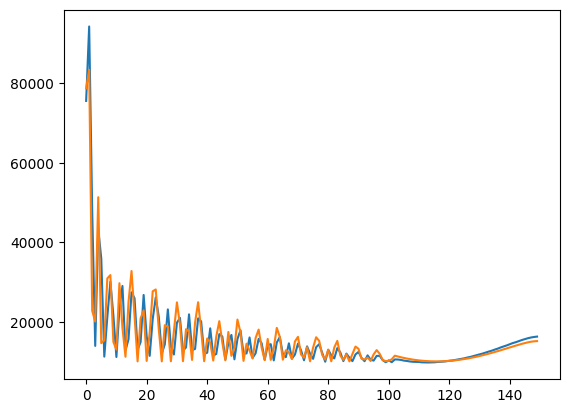

test_loss:  15731.795919484106


In [67]:
data_module = MSFTDataModule(allX, ally)
data_module.setup(day=32)
model = MSFT1DCNN(32)
train_dataloader = data_module.train_dataloader()
val_dataloader = data_module.val_dataloader()
test_dataloader = data_module.test_dataloader()

EPOCH = 150
training_losses, val_losses, test_losses = [], [], []
# training
model.train()
configs = model.configure_optimizers()
optimizer = configs
train_losses_by_epoch = []
val_losses_by_epoch = []
for epoch in range(EPOCH):
   training_losses = []
   for train_x, train_y in train_dataloader:
      #  print(train_x.shape, train_y.shape)
      #  train_x = train_x.reshape(-1, 32*20)
      #  print(train_x.shape)
       loss = model.training_step((train_x, train_y), 0)
       loss.backward()
       optimizer.step()
       training_losses.append(loss.item())
   train_losses_by_epoch.append(np.mean(training_losses))

   model.eval()
   with torch.no_grad():
      val_losses = []
      for val_x, val_y in val_dataloader:
        # val_x = val_x.reshape(-1, 100)
        loss = model.validation_step((val_x, val_y), 0)
        val_losses.append(loss.item())
      val_losses_by_epoch.append(np.mean(val_losses))

from matplotlib import pyplot as plt
plt.plot(train_losses_by_epoch, label='train')
plt.plot(val_losses_by_epoch, label='val')
plt.show()

model.eval()
with torch.no_grad():
    losses = []
    for test_x, test_y in test_dataloader:
      # test_x = test_x.reshape(-1, 100)
      loss = model.validation_step((test_x, test_y), 0)
      losses.append(loss.item())
print("test_loss: ", np.mean(losses))

# 3. Please try to enhance the performance of the previously created MLP or CNN by applying hyperparameter tuning. You can use tools such as W&B hyperparameter sweep, SMAP, Optuna, or similar packages to achieve this. You need to optimize at least two parameters, with the dropout rate being one of them. (5 points)










